In [1]:
!pip install google-play-scraper textblob seaborn nltk Sastrawi emoji wordcloud

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 14.9 MB/s eta 0:00:00


In [2]:
from google_play_scraper import app, Sort, reviews_all
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import string
import emoji

from textblob import TextBlob
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from wordcloud import WordCloud
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

nltk.download('punkt')
nltk.download('stopwords')

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (15,10)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [33]:
tix_reviews = reviews_all(
    'id.tix.android',
    lang='id',
    country='id',
    sort=Sort.NEWEST
)

df_tix = pd.DataFrame(np.array(tix_reviews), columns=['review'])
df_tix = df_tix.join(pd.DataFrame(df_tix.pop('review').tolist()))

print("Total Review:", len(df_tix))
df_tix.head()

df_tix.to_csv("tix_reviews_raw.csv", index=False)

Total Review: 96275


In [6]:
df_tix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96275 entries, 0 to 96274
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              96275 non-null  object        
 1   userName              96275 non-null  object        
 2   userImage             96275 non-null  object        
 3   content               96275 non-null  object        
 4   score                 96275 non-null  int64         
 5   thumbsUpCount         96275 non-null  int64         
 6   reviewCreatedVersion  85509 non-null  object        
 7   at                    96275 non-null  datetime64[ns]
 8   replyContent          49893 non-null  object        
 9   repliedAt             49893 non-null  datetime64[ns]
 10  appVersion            85509 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 8.1+ MB


In [7]:
df_analysis = df_tix.loc[:,[
    "content",
    "score",
    "thumbsUpCount",
    "reviewCreatedVersion",
    "at",
    "replyContent",
    "repliedAt"
]]

df_analysis.head()

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,suka Membantu .. bisa cek smua teater film,5,0,4.5.0,2026-03-09 10:17:35,"Hi TIX Hunter, terima kasih atas ulasan yang A...",2026-03-09 11:16:27
1,semoga kedepannya fitur Sinopsis film nya ada ...,3,3,4.4.0,2026-03-07 16:24:19,"Hi TIX Hunter, terima kasih atas review & sara...",2025-11-06 02:09:15
2,saya tidak bisa login kembali lepas tu saya lu...,1,0,None,2026-03-06 04:53:40,"Hi TIX Hunter, mohon maaf atas ketidaknyamanan...",2026-03-06 05:03:19
3,keren,5,0,4.4.0,2026-02-28 04:51:50,"TIX Hunter, terima kasih atas ulasan yang Anda...",2026-02-28 05:09:05
4,hemat waktu dan bisa pilih seat sesuka kita,5,0,4.4.0,2026-02-27 15:59:43,"TIX Hunter, terima kasih atas ulasan yang Anda...",2026-02-28 03:02:26


In [8]:
df_tix['score'].value_counts()

,count
score,
5,73921
4,9255
1,7591
3,3498
2,2010


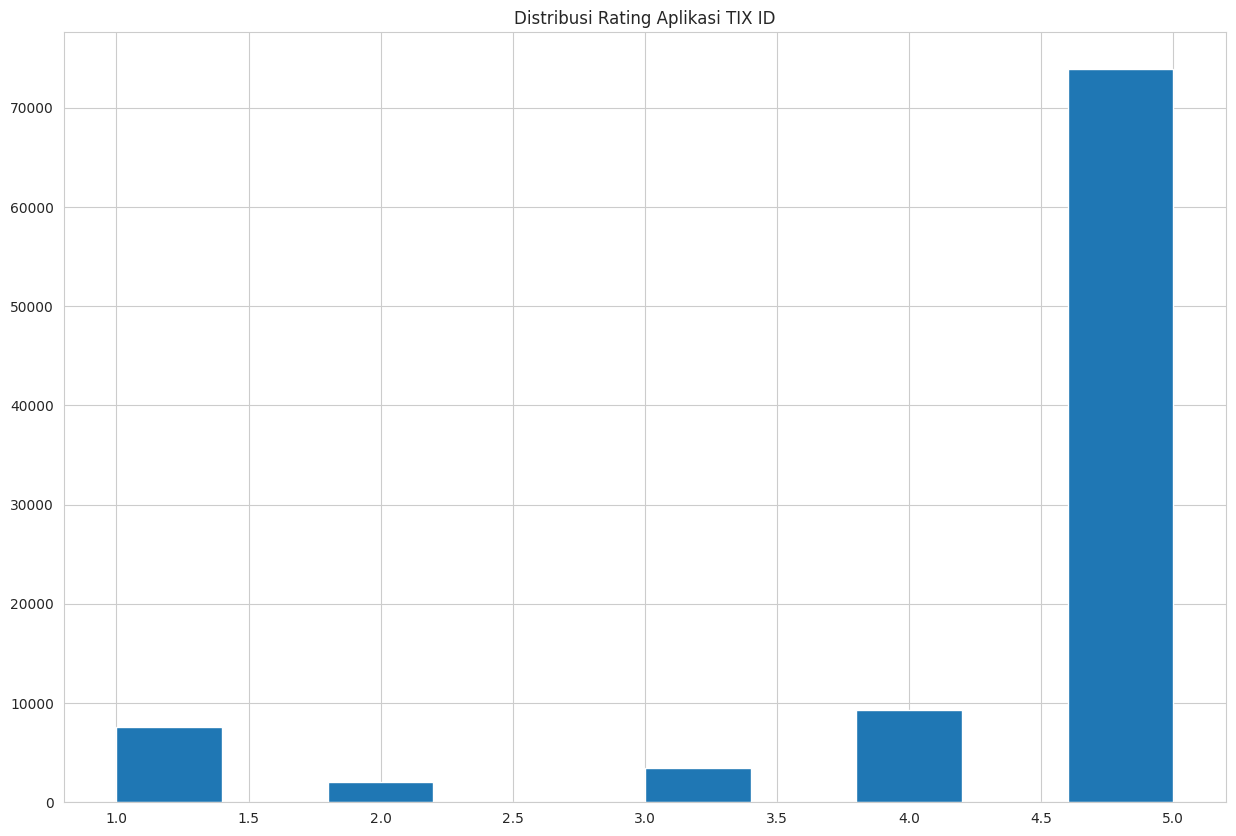

In [9]:
plt.hist(df_tix['score'])
plt.title("Distribusi Rating Aplikasi TIX ID")
plt.show()

In [10]:
df_tix['content'] = df_tix['content'].astype(str)

df_tix['sentiment_polarity'] = df_tix['content'].apply(lambda x: TextBlob(x).polarity)
df_tix['sentiment_subjective'] = df_tix['content'].apply(lambda x: TextBlob(x).subjectivity)

df_tix.loc[:,["content","score","sentiment_polarity","sentiment_subjective"]].head()

,content,score,sentiment_polarity,sentiment_subjective
0,suka Membantu .. bisa cek smua teater film,5,0.0,0.0
1,semoga kedepannya fitur Sinopsis film nya ada ...,3,0.0,0.0
2,saya tidak bisa login kembali lepas tu saya lu...,1,0.0,0.0
3,keren,5,0.0,0.0
4,hemat waktu dan bisa pilih seat sesuka kita,5,0.0,0.0


In [11]:
df_tix['content'] = df_tix['content'].apply(lambda x: x.lower())

df_tix.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,sentiment_polarity,sentiment_subjective
0,ae6121ad-0a2f-4188-b4dd-e36990dc224e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,suka membantu .. bisa cek smua teater film,5,0,4.5.0,2026-03-09 10:17:35,"Hi TIX Hunter, terima kasih atas ulasan yang A...",2026-03-09 11:16:27,4.5.0,0.0,0.0
1,790d3929-b2c0-44da-912e-277fce1a4f19,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,semoga kedepannya fitur sinopsis film nya ada ...,3,3,4.4.0,2026-03-07 16:24:19,"Hi TIX Hunter, terima kasih atas review & sara...",2025-11-06 02:09:15,4.4.0,0.0,0.0
2,f046cc42-17aa-42bb-a0d4-27bf9807b390,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,saya tidak bisa login kembali lepas tu saya lu...,1,0,None,2026-03-06 04:53:40,"Hi TIX Hunter, mohon maaf atas ketidaknyamanan...",2026-03-06 05:03:19,None,0.0,0.0
3,e1c32907-e79f-4c70-877b-c77e905ab3da,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,keren,5,0,4.4.0,2026-02-28 04:51:50,"TIX Hunter, terima kasih atas ulasan yang Anda...",2026-02-28 05:09:05,4.4.0,0.0,0.0
4,3f7747d8-b446-4c83-bb1a-0448b70608ad,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,hemat waktu dan bisa pilih seat sesuka kita,5,0,4.4.0,2026-02-27 15:59:43,"TIX Hunter, terima kasih atas ulasan yang Anda...",2026-02-28 03:02:26,4.4.0,0.0,0.0


In [13]:
indonesian_stopwords = stopwords.words('indonesian')

print(indonesian_stopwords[:20])

['ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara']


In [14]:
df_tix['wordCount'] = [len(review.split()) for review in df_tix['content']]
df_tix['uppercaseCharCount'] = [sum(char.isupper() for char in review) for review in df_tix['content']]
df_tix['specialCharCount'] = [sum(char in string.punctuation for char in review) for review in df_tix['content']]

df_tix.loc[:,["content","wordCount","uppercaseCharCount","specialCharCount"]]

,content,wordCount,uppercaseCharCount,specialCharCount
0,suka membantu .. bisa cek smua teater film,8,0,2
1,semoga kedepannya fitur sinopsis film nya ada ...,13,0,2
2,saya tidak bisa login kembali lepas tu saya lu...,25,0,3
3,keren,1,0,0
4,hemat waktu dan bisa pilih seat sesuka kita,8,0,0
...,...,...,...,...
96270,ini tuker tiket apa di langsung masuk,7,0,0
96271,pilih untuk tanggal berikutnya gk bs yah harus...,12,0,0
96272,suka dan lebih simple aplikasi yang ini,7,0,0
96273,sukaaaa aaa gaperlu antre lagi kalau mau bayar,8,0,0


In [15]:
df_tix['sentiment_rating'] = df_tix['score'].apply(
    lambda x: 'Positive' if x > 3 else ('Neutral' if x == 3 else 'Negative')
)

df_tix.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","sentiment_rating"]]

,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,suka membantu .. bisa cek smua teater film,5,0.0,0.000000,Positive
1,semoga kedepannya fitur sinopsis film nya ada ...,3,0.0,0.000000,Neutral
2,saya tidak bisa login kembali lepas tu saya lu...,1,0.0,0.000000,Negative
3,keren,5,0.0,0.000000,Positive
4,hemat waktu dan bisa pilih seat sesuka kita,5,0.0,0.000000,Positive
...,...,...,...,...,...
96270,ini tuker tiket apa di langsung masuk,5,0.0,0.000000,Positive
96271,pilih untuk tanggal berikutnya gk bs yah harus...,2,0.0,0.000000,Negative
96272,suka dan lebih simple aplikasi yang ini,5,0.0,0.357143,Positive
96273,sukaaaa aaa gaperlu antre lagi kalau mau bayar,5,0.0,0.000000,Positive


Text(0.5, 1.0, 'Google Play Store Mobile TIX ID Reviews Sentiment Analysis')

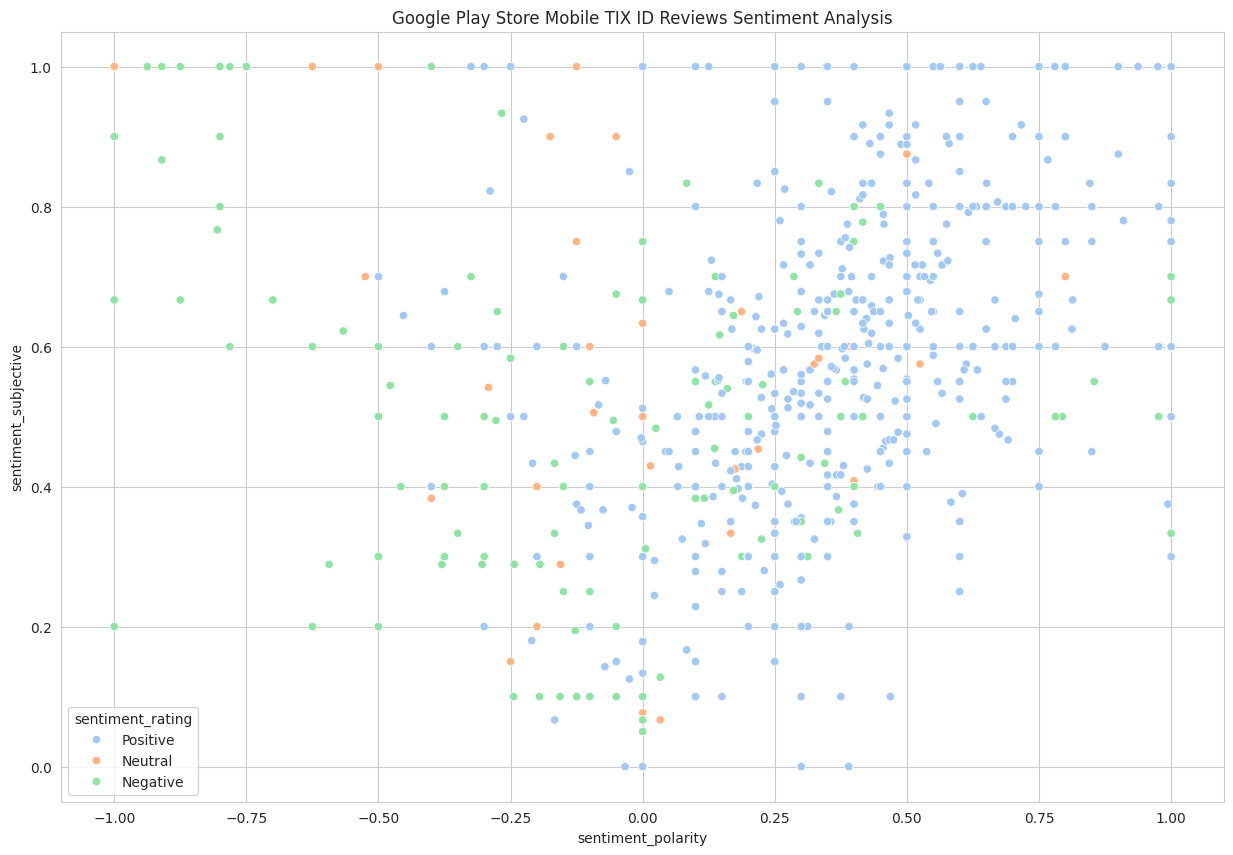

In [16]:
plt.figure(figsize=(15, 10))

sns.scatterplot(x=df_tix['sentiment_polarity'], y=df_tix['sentiment_subjective'],
                hue=df_tix['sentiment_rating'], edgecolor='white', palette='pastel')
plt.title("Google Play Store Mobile TIX ID Reviews Sentiment Analysis")

In [17]:
def freq_words(x, terms = 30):
  all_words = ' '.join([text for text in x])
  all_words = all_words.split()

  fdist = FreqDist(all_words)
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

  d = words_df.nlargest(columns="count", n = terms)
  plt.figure(figsize=(20,5))

  ax = sns.barplot(data=d, x="word", y="count", palette="rainbow")
  ax.set(ylabel = 'Count')
  plt.show()

/tmp/ipykernel_625/1712141617.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=d, x="word", y="count", palette="rainbow")


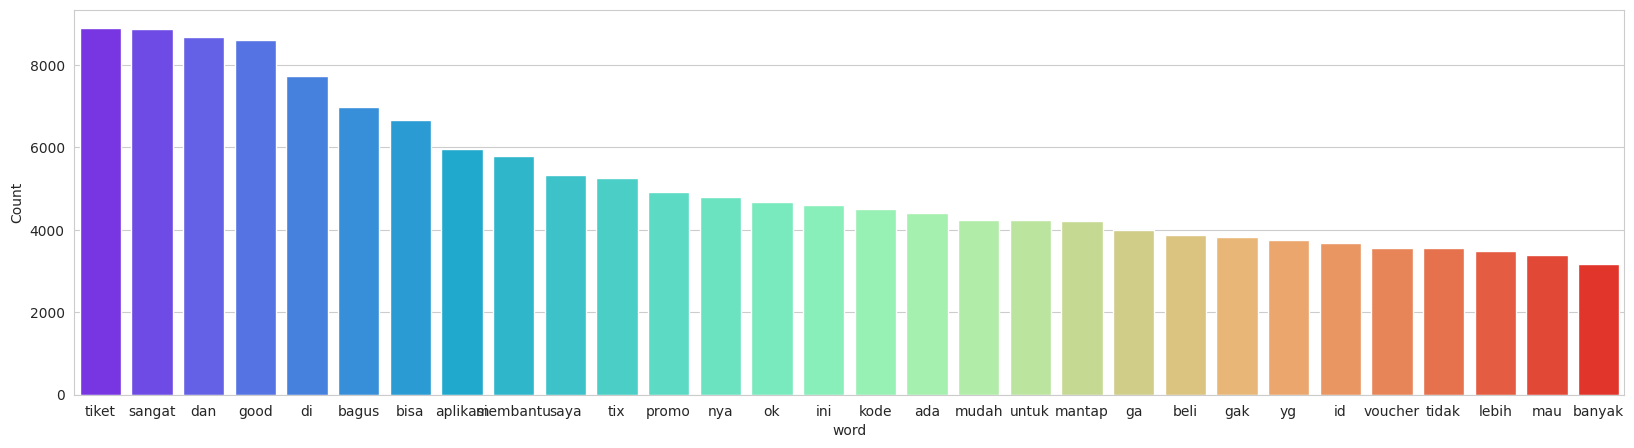

In [18]:
freq_words(df_tix['content'])

In [19]:
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

df_tix['content'] = df_tix['content'].apply(lambda x: stopword_remover.remove(x))

In [20]:
english_stopwords = stopwords.words('english')

df_tix['content'] = df_tix['content'].apply(lambda x: ' '.join([word for word in x.split() if word not in english_stopwords]))

In [31]:
len(english_stopwords)

198

In [27]:
df_tix.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","sentiment_rating"]]

,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,suka membantu .. cek smua teater film,5,0.0,0.000000,Positive
1,semoga kedepannya fitur sinopsis film nya baha...,3,0.0,0.000000,Neutral
2,tidak login lepas tu lupa password cuba ganti ...,1,0.0,0.000000,Negative
3,keren,5,0.0,0.000000,Positive
4,hemat waktu bisa pilih seat sesuka,5,0.0,0.000000,Positive
...,...,...,...,...,...
96270,tuker tiket apa langsung masuk,5,0.0,0.000000,Positive
96271,pilih tanggal berikutnya gk bs yah tanggal hari 😑,2,0.0,0.000000,Negative
96272,suka lebih simple aplikasi ini,5,0.0,0.357143,Positive
96273,sukaaaa aaa gaperlu antre kalau mau bayar,5,0.0,0.000000,Positive


In [28]:
def freq_words(x, terms = 30):
  all_words = ' '.join([text for text in x])
  all_words = all_words.split()

  fdist = FreqDist(all_words)
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

  d = words_df.nlargest(columns="count", n = terms)
  plt.figure(figsize=(20,5))

  ax = sns.barplot(data=d, x="word", y="count", palette="rainbow")
  ax.set(ylabel = 'Count')
  plt.show()

/tmp/ipykernel_625/1712141617.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=d, x="word", y="count", palette="rainbow")


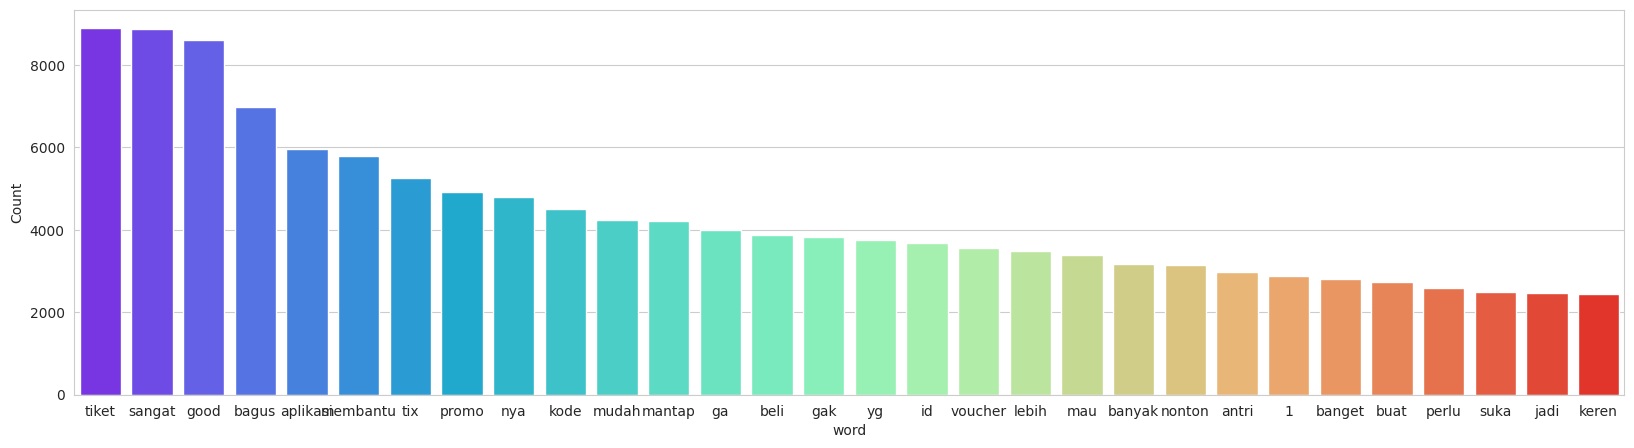

In [29]:
freq_words(df_tix['content'])

In [30]:
df_tix_stopwords = df_tix.copy()

df_tix_stopwords['wordCount'] = [
    len(review.split()) for review in df_tix_stopwords['content']
]

df_tix_stopwords['wordCount_after_stopwords'] = [
    len(review.split()) for review in df_tix_stopwords['content']
]

df_tix_stopwords.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,sentiment_polarity,sentiment_subjective,sentiment_rating,wordCount,uppercaseCharCount,specialCharCount,wordCount_after_stopwords
0,ae6121ad-0a2f-4188-b4dd-e36990dc224e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,suka membantu .. cek smua teater film,5,0,4.5.0,2026-03-09 10:17:35,"Hi TIX Hunter, terima kasih atas ulasan yang A...",2026-03-09 11:16:27,4.5.0,0.0,0.0,Positive,7,0,2,7
1,790d3929-b2c0-44da-912e-277fce1a4f19,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,semoga kedepannya fitur sinopsis film nya baha...,3,3,4.4.0,2026-03-07 16:24:19,"Hi TIX Hunter, terima kasih atas review & sara...",2025-11-06 02:09:15,4.4.0,0.0,0.0,Neutral,12,0,2,12
2,f046cc42-17aa-42bb-a0d4-27bf9807b390,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tidak login lepas tu lupa password cuba ganti ...,1,0,None,2026-03-06 04:53:40,"Hi TIX Hunter, mohon maaf atas ketidaknyamanan...",2026-03-06 05:03:19,None,0.0,0.0,Negative,15,0,3,15
3,e1c32907-e79f-4c70-877b-c77e905ab3da,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,keren,5,0,4.4.0,2026-02-28 04:51:50,"TIX Hunter, terima kasih atas ulasan yang Anda...",2026-02-28 05:09:05,4.4.0,0.0,0.0,Positive,1,0,0,1
4,3f7747d8-b446-4c83-bb1a-0448b70608ad,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,hemat waktu bisa pilih seat sesuka,5,0,4.4.0,2026-02-27 15:59:43,"TIX Hunter, terima kasih atas ulasan yang Anda...",2026-02-28 03:02:26,4.4.0,0.0,0.0,Positive,6,0,0,6
